In [61]:
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

from skimage.feature import hog
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

from scipy.spatial.distance import cdist
from google.colab import files
from google.colab.patches import cv2_imshow

#!unzip -q "dataset.zip" -d .


HOG Feature Extract

In [62]:
def Hog_extract(img, resize_to=(128,128)):
    if img is None:
        return None
    if len(img.shape) == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    gray = cv2.resize(gray, resize_to)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(32,32),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return features.astype("float32")


Dataset Loading

In [63]:
def load_dataset(dataset="dataset",resize_to=(128,128)):
    detector = dlib.get_frontal_face_detector()
    X, y = [], []
    label_map = {}
    label_id = 0
    valid_ext = (".jpg", ".jpeg", ".png", ".pgm")

    for person in sorted(os.listdir(dataset)):
        folder = os.path.join(dataset, person)
        if not os.path.isdir(folder):
            continue
        label_map[label_id] = person

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            if not img_path.lower().endswith(valid_ext):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                continue

            gray = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces, scores, idx = detector.run(gray, 1)

            if len(faces) == 0:
                face = img
            else:
                d = faces[0]
                score = scores[0]
                norm_score = max(0.2, min(score / 10, 1.0))
                adap_f = 0.35 * (1 / norm_score)
               # x, y0, w, h = d.left(), d.top(), d.width(), d.height()
                pad = int(0.35 * d.width())

                x1 = max(0, d.left()- pad)
                y1 = max(0, d.top() - pad)
                x2 = min(img.shape[1], d.right()+ pad) #x+w+pad
                y2 = min(img.shape[0], d.bottom()+ pad) #y0+h+pad

                face = img[y1:y2, x1:x2]

            H = Hog_extract(face)
            if H is not None:
                X.append(H)
                y.append(label_id)

        label_id += 1

    return np.array(X), np.array(y), label_map


Outlier Removal

In [64]:
X, y, label_map = load_dataset("dataset")
print("Loaded:", X.shape)

# 1. Low-norm removal
norms = np.linalg.norm(X, axis=1)
out_idx = np.where(norms < np.percentile(norms, 2))[0]
if len(out_idx) > 0:
    X = np.delete(X, out_idx, axis=0)
    y = np.delete(y, out_idx, axis=0)
print("After low-norm removal:", X.shape)




Loaded: (400, 324)
After low-norm removal: (393, 324)


Class Variance Weighting

In [65]:
# 2. Between-class variance weighting
classes = np.unique(y)
class_means = np.array([X[y == cls].mean(axis=0) for cls in classes])
between_var = np.var(class_means, axis=0)
eps = 1e-8
weights = (between_var + eps) / (np.mean(between_var) + eps)
#X = X * weights

Train/Val/Test Split

In [66]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.20, random_state=42, stratify=y_train_all
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (251, 324) Val: (63, 324) Test: (79, 324)


Logistic Regression

In [67]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("norm", Normalizer(norm="l2")),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
log_test = logreg.predict(X_test)


print(classification_report(y_test, log_test, target_names=[label_map[i] for i in sorted(label_map.keys())],zero_division=0))
print(" ")
avg_recall = recall_score(y_test, log_test, average='macro')
avg_pre = precision_score(y_test, log_test, average='macro', zero_division=0)
avg_f1 = f1_score(y_test, log_test, average='macro', zero_division=0)
print("Logistic Reg Accuracy:", accuracy_score(y_test, log_test))
print("Logistic Reg Recall:", avg_recall)
print("Logistic Reg Precision:", avg_pre)
print("Logistic Reg F1 Score:", avg_f1)



              precision    recall  f1-score   support

          s1       0.67      1.00      0.80         2
         s10       1.00      0.50      0.67         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         1
         s13       1.00      0.50      0.67         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       1.00      1.00      1.00         2
         s17       1.00      1.00      1.00         2
         s18       1.00      1.00      1.00         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       0.50      1.00      0.67         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s25       1.00    

KNN Classifier

In [68]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("norm", Normalizer(norm="l2")),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

knn.fit(X_train, y_train)
knn_test = knn.predict(X_test)
print(" ")


print(classification_report(y_test, knn_test,
                            target_names=[label_map[i] for i in sorted(label_map.keys())],
                            zero_division=0))
print(" ")
avg_recall = recall_score(y_test, knn_test, average='macro')
avg_pre = precision_score(y_test, knn_test, average='macro', zero_division=0)
avg_f1 = f1_score(y_test, knn_test, average='macro', zero_division=0)
print("KNN Accuracy:", accuracy_score(y_test, knn_test))
print("KNN Recall:", avg_recall)
print("KNN Precision:", avg_pre)
print("KNN F1 Score:", avg_f1)



 
              precision    recall  f1-score   support

          s1       0.67      1.00      0.80         2
         s10       0.33      0.50      0.40         2
         s11       1.00      1.00      1.00         2
         s12       0.00      0.00      0.00         1
         s13       0.67      1.00      0.80         2
         s14       0.67      1.00      0.80         2
         s15       1.00      1.00      1.00         2
         s16       0.50      0.50      0.50         2
         s17       0.67      1.00      0.80         2
         s18       1.00      1.00      1.00         2
         s19       1.00      1.00      1.00         2
          s2       0.67      1.00      0.80         2
         s20       1.00      0.50      0.67         2
         s21       0.67      1.00      0.80         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s25       0.67  

SVM Classifier

In [69]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("norm", Normalizer(norm="l2")),
    ("pca", PCA(n_components=0.98)),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True, class_weight="balanced"))
])

svm.fit(X_train, y_train)

svm_test = svm.predict(X_test)
svm_prob_test = svm.predict_proba(X_test)
print(" ")




print(classification_report(y_test, svm_test,
                            target_names=[label_map[i] for i in sorted(label_map.keys())],
                            zero_division=0))
print(" ")
avg_recall = recall_score(y_test, svm_test, average='macro')
avg_pre = precision_score(y_test, svm_test, average='macro', zero_division=0)
avg_f1 = f1_score(y_test, svm_test, average='macro', zero_division=0)
print("SVM Test Accuracy:", accuracy_score(y_test, svm_test))
print("SVM Recall:", avg_recall)
print("SVM Precision:", avg_pre)
print("SVM F1 Score:", avg_f1)



 
              precision    recall  f1-score   support

          s1       0.67      1.00      0.80         2
         s10       1.00      0.50      0.67         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         1
         s13       1.00      1.00      1.00         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       1.00      1.00      1.00         2
         s17       1.00      1.00      1.00         2
         s18       1.00      1.00      1.00         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       1.00      1.00      1.00         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s25       1.00  

In [70]:
val_probs = svm.predict_proba(X_val)
y_val_bin = label_binarize(y_val, classes=sorted(label_map.keys()))

op_threshold = {}

for i, cls in enumerate(sorted(label_map.keys())):
    fpr, tpr, thr = roc_curve(y_val_bin[:, i], val_probs[:, i])
    j = tpr - fpr
    idx = np.argmax(j)
    op_threshold[cls] = thr[idx]

print("Thresholds:")
for c in op_threshold:
    print(label_map[c], "->", round(op_threshold[c], 4))


Thresholds:
s1 -> 0.1071
s10 -> 0.1721
s11 -> 0.0772
s12 -> 0.1691
s13 -> 0.38
s14 -> 0.2236
s15 -> 0.1283
s16 -> 0.1376
s17 -> 0.2816
s18 -> 0.2381
s19 -> 0.1529
s2 -> 0.1257
s20 -> 0.0864
s21 -> 0.1422
s22 -> 0.3309
s23 -> 0.3871
s24 -> 0.0719
s25 -> 0.1833
s26 -> 0.1573
s27 -> 0.3291
s28 -> 0.084
s29 -> 0.3028
s3 -> 0.1642
s30 -> 0.1487
s31 -> 0.058
s32 -> 0.0365
s33 -> 0.1076
s34 -> 0.2526
s35 -> 0.082
s36 -> 0.03
s37 -> 0.2471
s38 -> 0.2627
s39 -> 0.4467
s4 -> 0.0839
s40 -> 0.1583
s5 -> 0.1909
s6 -> 0.0838
s7 -> 0.0941
s8 -> 0.3057
s9 -> 0.0535


Class Distribution Graph

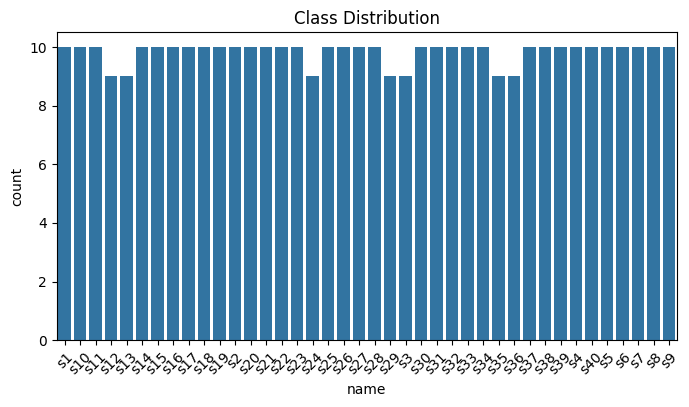

In [71]:
df = pd.DataFrame({"label": y})
df["name"] = df["label"].map(label_map)
plt.figure(figsize=(8,4))
sns.countplot(x=df["name"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


Heatmap

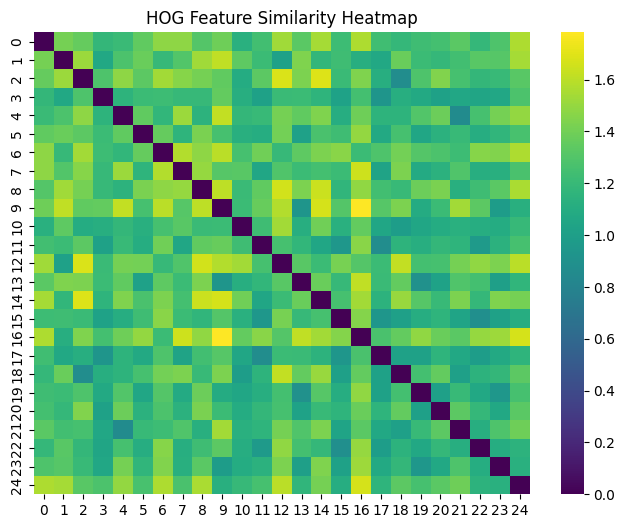

In [72]:
idx = np.random.choice(len(X), min(25, len(X)), replace=False)
mat = cdist(X[idx], X[idx])

plt.figure(figsize=(8,6))
sns.heatmap(mat, cmap="viridis")
plt.title("HOG Feature Similarity Heatmap")
plt.show()


ROC Curve

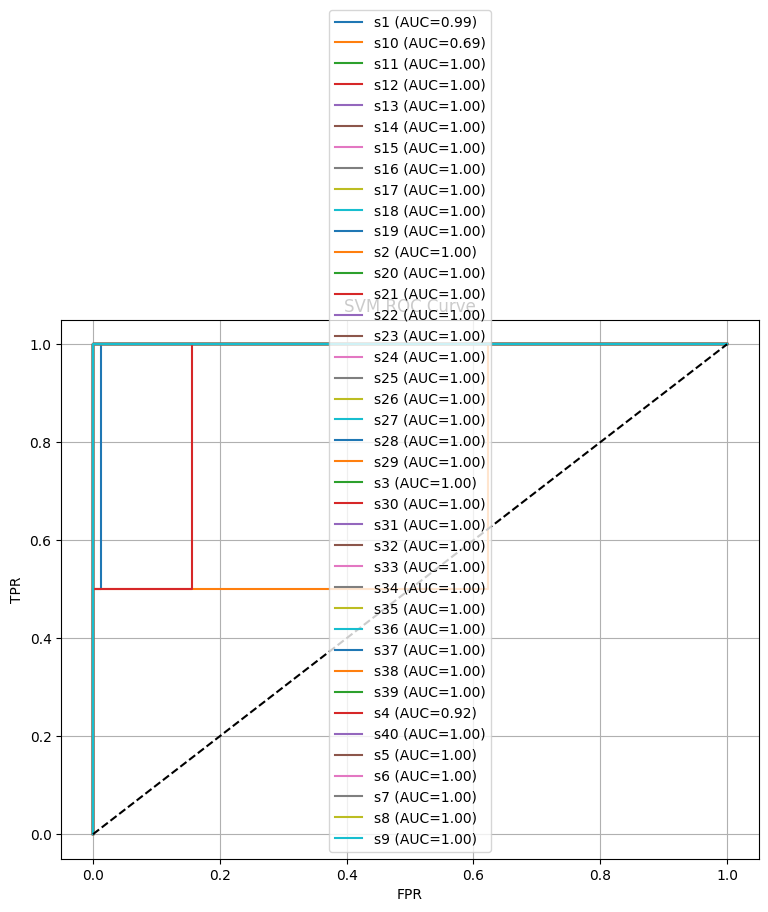

In [73]:
plt.figure(figsize=(9,7))
y_test_bin = label_binarize(y_test, classes=sorted(label_map.keys()))

for i, cls in enumerate(sorted(label_map.keys())):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], svm_prob_test[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_map[cls]} (AUC={auc_val:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("SVM ROC Curve")
plt.grid()
plt.show()


Saving 5.pgm to 5.pgm
Prediction: s38 (0.462)


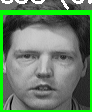

In [74]:
def predict_image():
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    img = cv2.imread(img_path)
    if img is None:
        print("Error loading image")
        return

    detector = dlib.get_frontal_face_detector()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces, scores, _ = detector.run(gray, 1)

    if len(faces) == 0:
        print("No face detected")
        cv2_imshow(img)
        return

    d = faces[0]
    pad = int(0.35 * d.width())

    x1 = max(0, d.left() - pad)
    y1 = max(0, d.top() - pad)
    x2 = min(img.shape[1], d.right() + pad)
    y2 = min(img.shape[0], d.bottom() + pad)

    face = img[y1:y2, x1:x2]
    hog_vec = Hog_extract(face)

    prob = svm.predict_proba([hog_vec])[0]
    best = np.argmax(prob)
    thr = min(op_threshold.get(best, 0.1), 0.40)
    safe_thr = min(thr, 0.30)

    if prob[best] < safe_thr:
        label = "Unknown"
        msg = f"Unknown (prob={prob[best]:.3f} < thr={thr:.3f})"
    else:
        label = label_map[best]
        msg = f"{label} ({prob[best]:.3f})"

    print("Prediction:", msg)

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
    cv2.putText(img, msg, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255,255,255), 2)
    cv2_imshow(img)
predict_image()


Joblib Save

In [75]:
joblib.dump(svm, "pipeline.joblib")
joblib.dump(op_threshold, "hog_svm.joblib")
np.save("Hog_labelMap.npy", label_map)

print("Model saved.")

accuracy_table = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM"],
    "Training Accuracy": [
        accuracy_score(y_train, logreg.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train))
    ],
    "Test Accuracy": [
        accuracy_score(y_test, log_test),
        accuracy_score(y_test, knn_test),
        accuracy_score(y_test, svm_test)
    ]
})

print("\nAccuracy Comparison:\n")
print(accuracy_table)

Model saved.

Accuracy Comparison:

                 Model  Training Accuracy  Test Accuracy
0  Logistic Regression           0.980080       0.886076
1                  KNN           0.956175       0.822785
2                  SVM           1.000000       0.924051
